In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from mne.time_frequency import psd_array_welch
import scipy.io
from scipy.stats import ttest_rel, f_oneway

In [2]:
def load_eeg_data(filepath):
    data = scipy.io.loadmat(filepath, struct_as_record=False, squeeze_me=True)
    return data



In [3]:
# Extract EEG epochs for Lemon vs Rose

def extract_odor_epochs(subject):
    eeg_data = subject.epoch
    odor_labels = np.array(subject.odor, dtype=int)
    lemon_trials = eeg_data[:, :, odor_labels == 0]
    rose_trials  = eeg_data[:, :, odor_labels == 1]
    return lemon_trials, rose_trials

In [4]:
# Preprocess EEG

def preprocess_eeg(trials, sfreq=200):
    if trials.ndim == 3:
        eeg_signal = trials.mean(axis=2)
    else:
        eeg_signal = trials

    #force contiguous copy (prevents BufferError)
    eeg_signal = np.ascontiguousarray(eeg_signal)

    n_channels, n_samples = eeg_signal.shape
    ch_names = [f"EEG{i+1}" for i in range(n_channels)]

    info = mne.create_info(
        ch_names=ch_names,
        sfreq=sfreq,
        ch_types="eeg"
    )

    raw = mne.io.RawArray(eeg_signal, info)

    
    raw.filter(0.5, 40, method='iir')

    return raw

In [5]:
# Extract Band Power
"""
def extract_band_power(raw):
    data = raw.get_data()
    sfreq = raw.info['sfreq']
    bands = {
        "Delta (1–4 Hz)": (1, 4),
        "Theta (4–8 Hz)": (4, 8),
        "Alpha (8–13 Hz)": (8, 13),
        "Beta (13–30 Hz)": (13, 30),
        "Gamma (30–40 Hz)": (30, 40)
    }
    band_power = {}
    for band, (fmin, fmax) in bands.items():
        psd, _ = psd_array_welch(data, sfreq=sfreq, fmin=fmin, fmax=fmax, average='mean')
        band_power[band] = psd.mean()
    return band_power
"""
def extract_band_power(raw, trials):
    """
    Computes band power by:
    trial → PSD → band power → average across trials & channels
    """
    sfreq = raw.info['sfreq']

    # trials shape: channels × samples × trials
    # Convert to trials × channels × samples
    data = np.transpose(trials, (2, 0, 1))

    bands = {
        "Delta (1–4 Hz)": (1, 4),
        "Theta (4–8 Hz)": (4, 8),
        "Alpha (8–13 Hz)": (8, 13),
        "Beta (13–30 Hz)": (13, 30),
        "Gamma (30–40 Hz)": (30, 40)
    }

    band_power = {}

    for band, (fmin, fmax) in bands.items():
        psd, _ = psd_array_welch(
            data,
            sfreq=sfreq,
            fmin=fmin,
            fmax=fmax,
            average='mean'
        )
        # psd shape: trials × channels
        band_power[band] = psd.mean()

    return band_power

In [6]:
# Compile results for all subjects in a group
def analyze_group(normalized_group, group_name):
    results_list = []
    for subj_idx, subject in enumerate(normalized_group):
        lemon_trials, rose_trials = extract_odor_epochs(subject)
        raw_lemon = preprocess_eeg(lemon_trials)
        raw_rose  = preprocess_eeg(rose_trials)
        #lemon_features = extract_band_power(raw_lemon)
        #rose_features  = extract_band_power(raw_rose)
        lemon_features = extract_band_power(raw_lemon, lemon_trials)
        rose_features  = extract_band_power(raw_rose, rose_trials)
        for band in lemon_features:
            results_list.append({
                "Group": group_name,
                "Subject": subj_idx+1,
                "EEG Band": band,
                "Lemon Power": lemon_features[band],
                "Rose Power": rose_features[band],
                "Difference (Rose - Lemon)": rose_features[band] - lemon_features[band]
            })
    df = pd.DataFrame(results_list)
    return df


In [7]:
filepaths = {
        "Normal": "normal.mat",
        "MCI": "MCI.mat",
        "AD": "AD.mat"
    }
# Explicit mapping for MATLAB struct keys
group_key_map = {
    "Normal": "normal",
    "MCI": "MCI",
    "AD": "AD"
    }

all_dfs = []
for group_name, filepath in filepaths.items():
    data = load_eeg_data(filepath)
    #print(f"{group_name} dataset loaded successfully.")
    key = group_key_map[group_name]
    group_df = analyze_group(data[key], group_name)
    all_dfs.append(group_df)

df_results = pd.concat(all_dfs, ignore_index=True)
df_results.to_csv("EEG_Odor_AllGroups_Results.csv", index=False)
print("\nAll group results saved.")

Creating RawArray with float64 data, n_channels=4, n_times=600
    Range : 0 ... 599 =      0.000 ...     2.995 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 0.50, 40.00 Hz: -6.02, -6.02 dB

Creating RawArray with float64 data, n_channels=4, n_times=600
    Range : 0 ... 599 =      0.000 ...     2.995 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 0.50, 40.00 Hz: -6.02, -6.02 dB

Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window siz

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

Setting up band-pass filter from 0.5 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 0.50, 40.00 Hz: -6.02, -6.02 dB

Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Creating RawArray with float64 data, n_channels=4, n_times=600
    Range : 0 ... 599 =      0.000 ...     2.995 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backw

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 0.50, 40.00 Hz: -6.02, -6.02 dB

Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Creating RawArray with float64 data, n_channels=4, n_times=600
    Range : 0 ... 599 =      0.000 ...     2.995 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 0.50, 40.00 Hz: -6.02, -6.02

...

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Effective window size : 1.280 (s)
Creating RawArray with float64 data, n_channels=4, n_times=600
    Range : 0 ... 599 =      0.000 ...     2.995 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 0.50, 40.00 Hz: -6.02, -6.02 dB

Creating RawArray with float64 data, n_channels=4, n_times=600
    Range : 0 ... 599 =      0.000 ...     2.995 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work


All group results saved.


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


In [8]:
# Statistical tests + Cohen's d

def statistical_tests_with_cohen(df):
    bands = df["EEG Band"].unique()
    stats_results = []
    for band in bands:
        band_data = df[df["EEG Band"] == band]
        t_stat, p_val = ttest_rel(band_data["Rose Power"], band_data["Lemon Power"])
        diff = band_data["Rose Power"] - band_data["Lemon Power"]
        cohen_d = diff.mean() / diff.std(ddof=1)
        stats_results.append({
            "EEG Band": band,
            "t-statistic": t_stat,
            "p-value": p_val,
            "Cohen_d": cohen_d
        })
    stats_df = pd.DataFrame(stats_results)
    return stats_df


In [9]:
# Within-group stats CSV
for group_name in df_results["Group"].unique():
        stats_df = statistical_tests_with_cohen(df_results[df_results["Group"]==group_name])
        print("\n" + group_name + " Paired t-test results with Cohen's d:\n", stats_df)
        stats_df.to_csv(f"EEG_Odor_{group_name}_Stats.csv", index=False)


Normal Paired t-test results with Cohen's d:
            EEG Band  t-statistic   p-value   Cohen_d
0    Delta (1–4 Hz)    -0.409440  0.688412 -0.105717
1    Theta (4–8 Hz)    -1.098426  0.290550 -0.283612
2   Alpha (8–13 Hz)    -1.037577  0.317057 -0.267901
3   Beta (13–30 Hz)    -1.072098  0.301810 -0.276815
4  Gamma (30–40 Hz)    -1.650961  0.120992 -0.426276

MCI Paired t-test results with Cohen's d:
            EEG Band  t-statistic   p-value   Cohen_d
0    Delta (1–4 Hz)    -0.368660  0.725040 -0.139340
1    Theta (4–8 Hz)    -1.522854  0.178625 -0.575585
2   Alpha (8–13 Hz)    -0.892281  0.406602 -0.337251
3   Beta (13–30 Hz)     0.293814  0.778799  0.111051
4  Gamma (30–40 Hz)     1.109554  0.309671  0.419372

AD Paired t-test results with Cohen's d:
            EEG Band  t-statistic   p-value   Cohen_d
0    Delta (1–4 Hz)    -1.489126  0.162259 -0.413009
1    Theta (4–8 Hz)    -1.257297  0.232566 -0.348711
2   Alpha (8–13 Hz)    -1.451585  0.172255 -0.402597
3   Beta (13–30 Hz

In [10]:
# Between-group comparison
def between_group_comparison(df, odor="Lemon Power"):
    bands = df["EEG Band"].unique()
    results = []
    for band in bands:
        band_data = df[df["EEG Band"] == band]
        groups = [band_data[band_data["Group"] == g][odor].values for g in ["Normal","MCI","AD"]]
        f_stat, p_val = f_oneway(*groups)
        results.append({
            "EEG Band": band,
            "F-statistic": f_stat,
            "p-value": p_val
        })
    return pd.DataFrame(results)



In [11]:
# Between-group ANOVA CSV
for odor in ["Lemon Power","Rose Power"]:
    bg_stats = between_group_comparison(df_results, odor)
    bg_stats.to_csv(f"EEG_Odor_BetweenGroups_{odor.replace(' ','_')}.csv", index=False)
    

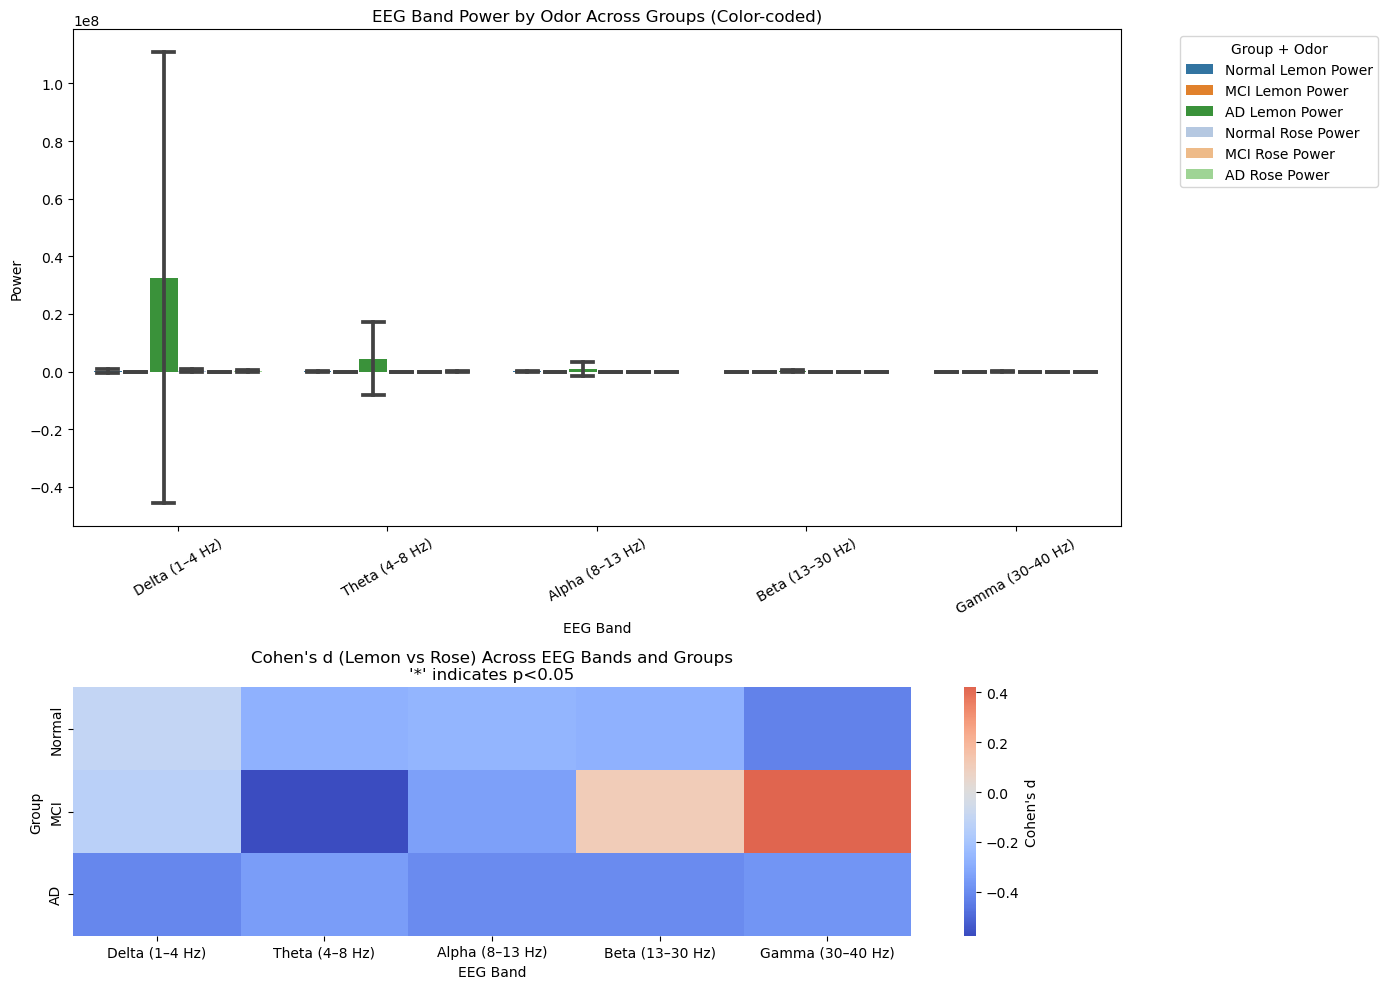

In [12]:
#Plot combined figure
df = df_results
fig, axes = plt.subplots(2,1, figsize=(14,10), gridspec_kw={'height_ratios':[2,1]})

    # --- Top subplot: color-coded bar plot by group ---
df_melted = df.melt(
    id_vars=["Group","Subject","EEG Band"],
    value_vars=["Lemon Power","Rose Power"],
    var_name="Odor",
    value_name="Power"
 )
df_melted["Group_Odor"] = df_melted["Group"] + " " + df_melted["Odor"]

# Define a color palette for each group + odor
palette = {
    "Normal Lemon Power":"#1f77b4",
    "Normal Rose Power":"#aec7e8",
    "MCI Lemon Power":"#ff7f0e",
    "MCI Rose Power":"#ffbb78",
    "AD Lemon Power":"#2ca02c",
    "AD Rose Power":"#98df8a"
 }

sns.barplot(
    ax=axes[0],
    data=df_melted,
    x="EEG Band",
    y="Power",
    hue="Group_Odor",
    errorbar="sd",
    palette=palette,
    capsize=0.1
)

axes[0].set_title("EEG Band Power by Odor Across Groups (Color-coded)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
axes[0].legend(title="Group + Odor", bbox_to_anchor=(1.05, 1), loc='upper left')

# --- Bottom subplot: Cohen's d heatmap ---
heatmap_data = []
signif_marks = []
for group_name in df["Group"].unique():
    group_df = df[df["Group"] == group_name]
    bands = group_df["EEG Band"].unique()
    cohen_d_list = []
    marks = []
    for band in bands:
        band_data = group_df[group_df["EEG Band"] == band]
        diff = band_data["Rose Power"] - band_data["Lemon Power"]
        cohen_d = diff.mean() / diff.std(ddof=1)
        cohen_d_list.append(cohen_d)
        t_stat, p_val = ttest_rel(band_data["Rose Power"], band_data["Lemon Power"])
        marks.append("*" if p_val < 0.05 else "")
    heatmap_data.append(cohen_d_list)
    signif_marks.append(marks)

heatmap_df = pd.DataFrame(heatmap_data, index=df["Group"].unique(), columns=bands)
signif_df = pd.DataFrame(signif_marks, index=df["Group"].unique(), columns=bands)

sns.heatmap(
    heatmap_df,
    annot=signif_df,
    fmt='',
    cmap="coolwarm",
    center=0,
    cbar_kws={'label': "Cohen's d"},
    ax=axes[1]
)
axes[1].set_title("Cohen's d (Lemon vs Rose) Across EEG Bands and Groups\n'*' indicates p<0.05")
axes[1].set_ylabel("Group")
axes[1].set_xlabel("EEG Band")

plt.tight_layout()
plt.show()